# Tandem AoI simulation: corrected joint FGMW vs isolated MW

This notebook combines the original tandem simulation with the V3 debugging patch and regression tests.
It keeps the original two-stage model and policy comparison, while correcting the issues that can distort
throughput, utilization, and lower-bound conclusions.

**Implemented corrections**

- a KKT/bisection rate optimizer with feasibility and stationarity checks;
- coherent empty-pipeline initialization, $h_i(0)=L+1$ and $A_i^Q(0)=L$;
- separate lifetime and post-warmup event counters;
- actual Stage-1 and Stage-2 resource-use accounting;
- overwrite, same-slot refill, empty-idle, nonempty-idle, occupancy, and fresh-gap diagnostics;
- common environmental randomness with separate Stage-1 and Stage-2 policy RNGs;
- trajectory-level structural checks, including
  $h_i\le A_i^Q+Q_i+Y_i+1$;
- both theorem-style SRP2 and a work-conserving SRP2 ablation;
- no stale embedded sweep output, and no certified FGMW claim for $L=1$.

The relaxed isolated Stage-2 program uses only $\sum_i q_i\le\mu$. Its optimizer is therefore a
**lambda-agnostic certificate/tuning vector**, not necessarily an achievable tandem delivery-rate vector.


In [17]:
from __future__ import annotations

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tandem.config import make_symmetric_network
from tandem.diagnostics import estimate_iso1_voq_arrival_rates, paired_replications, validate_run_result
from tandem.policies import (
    ComposedV3,
    GreedyBSV3,
    GreedyESV3,
    IsoBSV3,
    IsoESV3,
    JointBSV3,
    JointESV3,
    SRPBSV3,
    TheoremSRPESV3,
    UniformBSV3,
    UniformESV3,
    WorkConservingSRPESV3,
    build_experiment_v3,
    build_iso1_iso2_lambda_policy_v3,
    build_policies_v3,
)
from tandem.rate_optimizer import (
    iso1_params_v3,
    iso2_lambda_params_v3,
    iso2_params_v3,
    joint_params_v3,
    lb_bsside_v3,
    lb_dest_iso2_relaxed_v3,
    lb_dest_joint_v3,
    solve_capped_edge_rate_kkt,
    solve_rate_kkt,
)
from tandem.simulator import TandemAoISimulatorV3
from tandem import plotting as tandem_plotting

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)


## 1. Convex rate programs and Lyapunov coefficients

The common rate objective is

\[
\min_{q_i>0}\sum_i\left(\frac{w_i}{2q_i}+g_iq_i\right),
\]

with an optional Stage-1 constraint

\[
\sum_i\left(L-1+\frac{1}{p_i}\right)q_i\le 1
\]

and an optional Stage-2 constraint $\sum_iq_i\le\mu$. The KKT form is

\[
q_i=\sqrt{\frac{w_i}{2(g_i+\lambda c_i+\nu)}}.
\]

The implementation below solves for the nonnegative multipliers by nested monotone bisection and verifies
primal feasibility and stationarity before returning any coefficients.


In [18]:
# =====================================================================
# Reliable convex rate solver
# =====================================================================
# Reusable optimizer code now lives in tandem.rate_optimizer and is imported above.


## 2. Corrected tandem simulator

A slot first reads the beginning-of-slot state and makes eligible Stage-1/Stage-2 decisions, then realizes
the gate and service coins, and finally constructs the next-slot state. A Stage-1 arrival generated in slot
$k$ cannot be selected by Stage 2 until slot $k+1$.

The measured event rates and resource fractions below are all based on exactly the same post-warmup slots as
the AoI averages. Lifetime counters are retained separately for finite-horizon conservation checks.


In [19]:
# =====================================================================
# Corrected simulator and diagnostics
# =====================================================================
# Reusable simulator dynamics now live in tandem.simulator.
# Post-warmup accounting helpers live in tandem.diagnostics.


## 3. Composable policy layer

The joint and isolated policies are assembled from independent Stage-1 and Stage-2 controllers. Random ties
are broken without source-index bias. Two randomized Stage-2 baselines are retained:

- **theorem-SRP2:** sample from all sources and idle when the sampled VOQ is empty;
- **WC-SRP2:** renormalize over currently nonempty VOQs, isolating age-blind prioritization from avoidable idling.

For $L=1$, the simulator remains valid, but the supplied $L>1$ FGMW derivations are not automatically claimed;
`build_policies_v3` rejects that case unless the empirical extension is explicitly enabled.


In [20]:
# =====================================================================
# Controllers with stage-specific policy RNG and unbiased tie-breaking
# =====================================================================
# Reusable policy classes and experiment builders now live in tandem.policies.


## 4. Regression tests

These tests check an exact one-source trajectory, randomized KKT feasibility, Stage-1 path independence from
the Stage-2 controller under separated RNG streams, post-warmup accounting, and the structural bridge.
They fail with assertions rather than printing an unconditional success message.


In [21]:
class AlwaysServeOneSource:
    def decide(self, sim):
        u_bs = 0 if sim.B == -1 else -1
        u_es = 0 if sim.J == -1 and sim.V[0] else -1
        return u_bs, u_es


def run_regression_tests():
    # Exact deterministic one-source cycles under the notebook's +2 reset convention.
    for L in (1, 2, 3, 5):
        r = TandemAoISimulatorV3(1, L, [1.0], 1.0, [1.0], seed=1).run(
            AlwaysServeOneSource(), K=500, warmup=50, validate=True
        )
        np.testing.assert_allclose(r["weighted_bsside_age"], 1.5 * L - 0.5, atol=1e-12)
        np.testing.assert_allclose(r["weighted_dest_aoi"], 1.5 * L + 1.5, atol=1e-12)

    # Heterogeneous KKT stress test.
    rng = np.random.default_rng(4)
    for _ in range(60):
        N = int(rng.integers(1, 12))
        L = int(rng.integers(2, 10))
        p = np.exp(rng.uniform(np.log(0.02), 0.0, N))
        mu = float(np.exp(rng.uniform(np.log(0.02), 0.0)))
        w = np.exp(rng.uniform(np.log(0.05), np.log(50.0), N))
        c = L - 1.0 + 1.0 / p
        g = w * (1.0 - mu) / mu**2
        q, _ = solve_rate_kkt(w, g, link_c=c, edge_cap=mu)
        assert c @ q <= 1.0 + 1e-9
        assert q.sum() <= mu + 1e-9
        assert np.all(q > 0.0)

    # Stage-1 evolution must not depend on the Stage-2 controller.
    N, L, p, mu, w = 6, 3, [0.6] * 6, 0.6, [1, 1, 1, 4, 4, 4]
    policies, _ = build_experiment_v3(N, L, p, mu, w)
    r_mw = TandemAoISimulatorV3(N, L, p, mu, w, seed=8).run(
        policies["iso1 + iso2"], K=3000, warmup=0, record_series=True
    )
    r_srp = TandemAoISimulatorV3(N, L, p, mu, w, seed=8).run(
        policies["iso1 + WC-SRP2"], K=3000, warmup=0, record_series=True
    )
    np.testing.assert_array_equal(r_mw["series"]["Aq"], r_srp["series"]["Aq"])

    # Anchor accounting and structural invariant.
    K, warmup = 10_000, 1_000
    r = TandemAoISimulatorV3(N, L, p, mu, w, seed=0).run(
        policies["Joint FGMW"], K=K, warmup=warmup, validate=True
    )
    validate_run_result(r, K, L)
    assert r["max_bridge_violation"] <= 1e-10
    assert r["s1_used_frac"] <= 1.0 + 1e-12
    assert r["s2_used_frac"] <= 1.0 + 1e-12

    print("All tandem regression tests passed.")


run_regression_tests()


All tandem regression tests passed.


## 5. Anchor configuration

The original symmetric anchor is retained for continuity:

\[
N=6,\quad L=3,\quad p_i=0.6,\quad \mu=0.6,\quad
w=(1,1,1,4,4,4).
\]

Because all $p_i$ are equal, the joint link constraint has a common coefficient. This anchor is useful for
validation, but it is not the strongest setting for exposing genuinely different joint and isolated rate
allocations.


In [22]:
ANCHOR = dict(
    N=6,
    L=3,
    p=np.array([0.6] * 6),
    mu=0.6,
    w=np.array([1.0, 1.0, 1.0, 4.0, 4.0, 4.0]),
)

N, L, p, mu, w = (ANCHOR[k] for k in ("N", "L", "p", "mu", "w"))
anchor_policies, anchor_params = build_experiment_v3(N, L, p, mu, w)

print("q^dagger, joint       =", anchor_params["joint"]["qd"])
print("q^dagger, isolated S1 =", anchor_params["iso1"]["qd"])
print("q^dagger, relaxed S2  =", anchor_params["iso2"]["qd"])
print("joint duals           =", anchor_params["joint"]["dual"])
print("BS-side lower bound   =", round(anchor_params["lb_bsside"], 6))
print("joint destination LB  =", round(anchor_params["lb_dest_joint"], 6))
print("relaxed S2 dest. LB   =", round(anchor_params["lb_dest_iso2_relaxed"], 6))


q^dagger, joint       = [0.030365 0.030365 0.030365 0.060544 0.060544 0.060544]
q^dagger, isolated S1 = [0.030303 0.030303 0.030303 0.060606 0.060606 0.060606]
q^dagger, relaxed S2  = [0.06733 0.06733 0.06733 0.13267 0.13267 0.13267]
joint duals           = {'lambda_link': 147.5918382156524, 'nu_edge': 0.0, 'link_usage': 0.9999999999999626, 'edge_usage': 0.2727272727272625}
BS-side lower bound   = 31.0
joint destination LB  = 36.151464
relaxed S2 dest. LB   = 22.832782


In [23]:
ANCHOR_ORDER = [
    "Joint FGMW",
    "iso1 + iso2",
    "iso1 + WC-SRP2",
    "iso1 + theorem-SRP2",
    "SRP1 + iso2",
    "Greedy",
    "Uniform",
]
K_ANCHOR, WARM_ANCHOR, ANCHOR_SEED = 30_000, 3_000, 0

anchor_results = {}
rows = []
for name in ANCHOR_ORDER:
    result = TandemAoISimulatorV3(N, L, p, mu, w, seed=ANCHOR_SEED).run(
        anchor_policies[name], K=K_ANCHOR, warmup=WARM_ANCHOR, validate=True
    )
    validate_run_result(result, K_ANCHOR, L)
    anchor_results[name] = result
    rows.append({
        "policy": name,
        "Aq": result["weighted_bsside_age"],
        "Aq/LB": result["weighted_bsside_age"] / anchor_params["lb_bsside"],
        "h": result["weighted_dest_aoi"],
        "h/LB": result["weighted_dest_aoi"] / anchor_params["lb_dest_joint"],
        "sum_w_h": N * result["weighted_dest_aoi"],
        "VOQ arrivals": result["VOQ_arrival_rate"].sum(),
        "deliveries": result["stage2_delivery_rate"].sum(),
        "overwrites": result["overwrite_rate"].sum(),
        "S1 used": result["s1_used_frac"],
        "S2 used": result["s2_used_frac"],
        "S2 idle-empty": result["s2_idle_empty_frac"],
        "S2 idle-nonempty": result["s2_idle_nonempty_frac"],
    })

anchor_table = pd.DataFrame(rows).set_index("policy")
anchor_table.round(4)


,Aq,Aq/LB,h,h/LB,sum_w_h,VOQ arrivals,deliveries,overwrites,S1 used,S2 used,S2 idle-empty,S2 idle-nonempty
policy,,,,,,,,,,,,
Joint FGMW,31.3920,1.0126,38.2865,1.0591,229.7190,0.2737,0.2737,0.0000,1.0,0.4562,0.5438,0.0000
iso1 + iso2,31.4508,1.0145,38.3891,1.0619,230.3347,0.2734,0.2734,0.0000,1.0,0.4573,0.5427,0.0000
iso1 + WC-SRP2,31.4508,1.0145,38.3922,1.0620,230.3534,0.2734,0.2734,0.0000,1.0,0.4573,0.5427,0.0000
iso1 + theorem-SRP2,31.4508,1.0145,51.5169,1.4250,309.1013,0.2734,0.2612,0.0122,1.0,0.4353,0.0371,0.5276
SRP1 + iso2,51.7982,1.6709,58.5889,1.6207,351.5334,0.2737,0.2732,0.0005,1.0,0.4502,0.5498,0.0000
Greedy,33.2138,1.0714,40.1511,1.1106,240.9067,0.2724,0.2724,0.0000,1.0,0.4550,0.5450,0.0000
Uniform,57.7038,1.8614,64.5766,1.7863,387.4599,0.2731,0.2728,0.0003,1.0,0.4560,0.5440,0.0000


### Per-source pipeline diagnostics

The comparison below places the offline tuning vectors beside the achieved VOQ-arrival and destination-delivery
rates. They should not be expected to coincide: max-weight uses $q^\dagger$ to tune coefficients rather than
enforcing a target rate vector.


In [24]:
joint_r = anchor_results["Joint FGMW"]
iso_r = anchor_results["iso1 + iso2"]

per_source_anchor = pd.DataFrame({
    "source": np.arange(N),
    "p": p,
    "w": w,
    "q_joint": anchor_params["joint"]["qd"],
    "q_iso1": anchor_params["iso1"]["qd"],
    "q_iso2_relaxed": anchor_params["iso2"]["qd"],
    "arr_joint": joint_r["VOQ_arrival_rate"],
    "deliv_joint": joint_r["stage2_delivery_rate"],
    "occ_joint": joint_r["VOQ_occupancy"],
    "Q_joint": joint_r["avg_fresh_gap_Q"],
    "arr_iso": iso_r["VOQ_arrival_rate"],
    "deliv_iso": iso_r["stage2_delivery_rate"],
    "occ_iso": iso_r["VOQ_occupancy"],
    "Q_iso": iso_r["avg_fresh_gap_Q"],
})
per_source_anchor.round(5)


,source,p,w,q_joint,q_iso1,q_iso2_relaxed,arr_joint,deliv_joint,occ_joint,Q_joint,arr_iso,deliv_iso,occ_iso,Q_iso
0,0,0.6,1.0,0.03036,0.03030,0.06733,0.03107,0.03107,0.03389,1.12485,0.03133,0.03133,0.03570,1.17074
1,1,0.6,1.0,0.03036,0.03030,0.06733,0.03107,0.03107,0.03493,1.15807,0.03137,0.03133,0.03596,1.18133
2,2,0.6,1.0,0.03036,0.03030,0.06733,0.03107,0.03107,0.03452,1.14196,0.03133,0.03137,0.03489,1.14219
3,3,0.6,4.0,0.06054,0.06061,0.13267,0.06019,0.06015,0.06656,1.16604,0.05978,0.05981,0.06563,1.16100
4,4,0.6,4.0,0.06054,0.06061,0.13267,0.06015,0.06015,0.06548,1.14889,0.05978,0.05978,0.06581,1.16322
5,5,0.6,4.0,0.06054,0.06061,0.13267,0.06015,0.06019,0.06567,1.15574,0.05978,0.05978,0.06544,1.15922


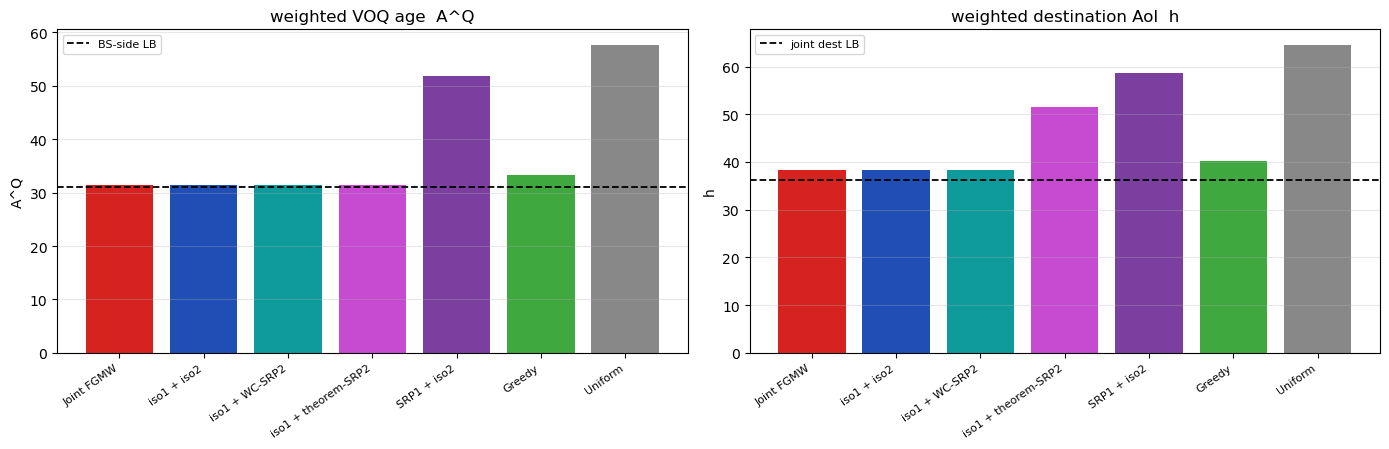

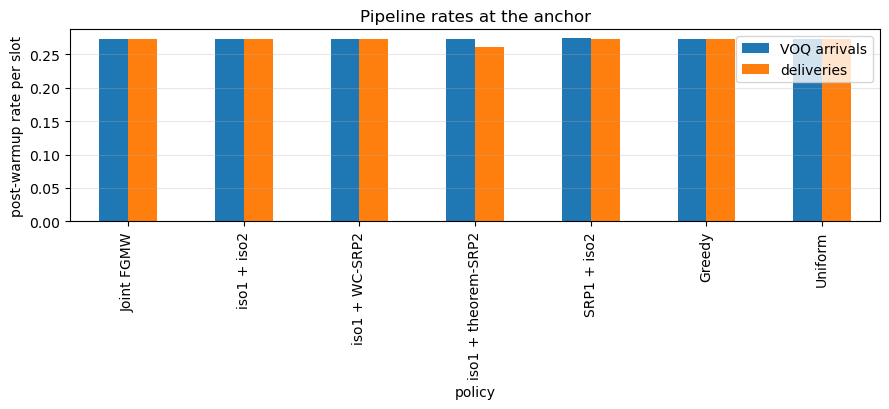

In [25]:
# Anchor policy comparison on both objectives, with lower-bound lines.
order_bar = ANCHOR_ORDER
fig, ax = tandem_plotting.plot_anchor_objectives(anchor_table, anchor_params, order_bar)
plt.show()

# pipeline rates (kept from the original)
fig, ax = tandem_plotting.plot_pipeline_rates(anchor_table)
plt.show()


## 6. Paired replications: Joint FGMW versus two isolated MW controllers

Each seed supplies the same slot-indexed environmental randomness to both policies. The reported interval is a
normal-approximation confidence interval for the paired difference
$\bar h_{\rm joint}-\bar h_{\rm isolated}$; it is a simulation diagnostic, not a theorem.


In [26]:
paired_anchor = paired_replications(
    anchor_policies["Joint FGMW"],
    anchor_policies["iso1 + iso2"],
    N, L, p, mu, w,
    seeds=range(6),
    K=15_000,
    warmup=1_500,
)

pd.Series({
    "mean Joint FGMW": paired_anchor["mean_a"],
    "mean isolated MW": paired_anchor["mean_b"],
    "mean difference (joint-isolated)": paired_anchor["mean_difference_a_minus_b"],
    "SE of paired difference": paired_anchor["standard_error_difference"],
    "95% CI lower": paired_anchor["approx_95pct_CI_difference"][0],
    "95% CI upper": paired_anchor["approx_95pct_CI_difference"][1],
}).round(6)


mean Joint FGMW                     38.415545
mean isolated MW                    38.380383
mean difference (joint-isolated)     0.035163
SE of paired difference              0.082595
95% CI lower                        -0.126724
95% CI upper                         0.197049
dtype: float64

## 7. Stronger heterogeneous, dual-active stress case

A symmetric common-$p$ experiment collapses the link constraint to a scalar sum-rate cap. The following case
uses heterogeneous channels and chooses $\mu$ so that both joint KKT multipliers are positive. This makes the
link and edge constraints simultaneously shape $q^\dagger$ and is therefore a more informative structural test.


In [27]:
STRESS = dict(
    N=6,
    L=3,
    p=np.array([0.95, 0.80, 0.60, 0.35, 0.20, 0.10]),
    mu=0.15,
    w=np.array([1.0, 1.0, 2.0, 4.0, 6.0, 10.0]),
)

Ns, Ls, ps, mus, ws = (STRESS[k] for k in ("N", "L", "p", "mu", "w"))
stress_policies, stress_params = build_experiment_v3(Ns, Ls, ps, mus, ws)
print("joint duals:", stress_params["joint"]["dual"])
print("joint q^dagger:", stress_params["joint"]["qd"])
print("isolated-S1 q^dagger:", stress_params["iso1"]["qd"])
print("relaxed-S2 q^dagger:", stress_params["iso2"]["qd"])

stress_rows = []
stress_results = {}
for name in ANCHOR_ORDER:
    r = TandemAoISimulatorV3(Ns, Ls, ps, mus, ws, seed=2).run(
        stress_policies[name], K=25_000, warmup=2_500, validate=True
    )
    validate_run_result(r, 25_000, Ls)
    stress_results[name] = r
    stress_rows.append({
        "policy": name,
        "Aq": r["weighted_bsside_age"],
        "h": r["weighted_dest_aoi"],
        "h/LB": r["weighted_dest_aoi"] / stress_params["lb_dest_joint"],
        "arrivals": r["VOQ_arrival_rate"].sum(),
        "deliveries": r["stage2_delivery_rate"].sum(),
        "overwrites": r["overwrite_rate"].sum(),
        "S2 idle-nonempty": r["s2_idle_nonempty_frac"],
    })

stress_table = pd.DataFrame(stress_rows).set_index("policy")
stress_table.round(4)


joint duals: {'lambda_link': 83.00851269220584, 'nu_edge': 1969.854141346179, 'link_usage': 0.9999999999999966, 'edge_usage': 0.14999999999999356}
joint q^dagger: [0.014871 0.014817 0.020629 0.028149 0.032865 0.03867 ]
isolated-S1 q^dagger: [0.020368 0.01974  0.026282 0.032294 0.032946 0.032485]
relaxed-S2 q^dagger: [0.014027 0.014027 0.019691 0.027448 0.033149 0.041658]


,Aq,h,h/LB,arrivals,deliveries,overwrites,S2 idle-nonempty
policy,,,,,,,
Joint FGMW,87.8427,155.7460,1.7163,0.1868,0.1402,0.0467,0.0000
iso1 + iso2,83.9551,153.3513,1.6899,0.1782,0.1385,0.0397,0.0000
iso1 + WC-SRP2,83.9551,172.1819,1.8974,0.1782,0.1397,0.0385,0.0000
iso1 + theorem-SRP2,83.9551,191.6027,2.1114,0.1782,0.1264,0.0519,0.1497
SRP1 + iso2,134.1463,192.6801,2.1233,0.1676,0.1326,0.0351,0.0000
Greedy,97.7264,167.4760,1.8456,0.1362,0.1251,0.0112,0.0000
Uniform,281.5530,390.7237,4.3057,0.2506,0.1475,0.1031,0.0000


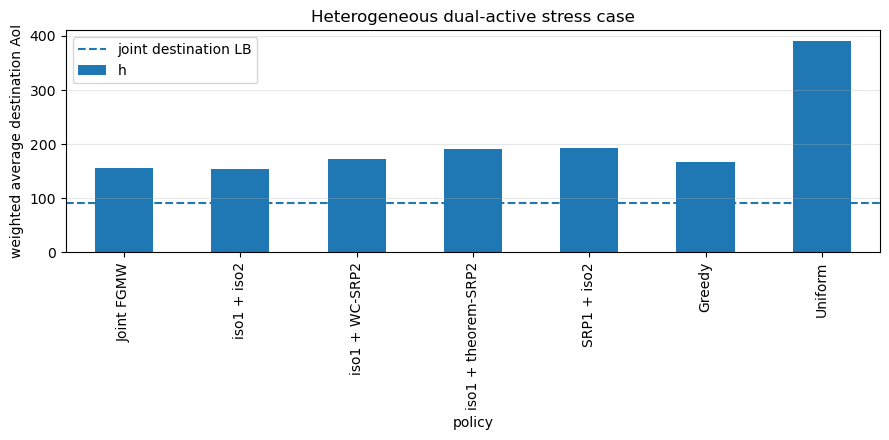

In [28]:
fig, ax = tandem_plotting.plot_stress_dest_aoi(stress_table, stress_params)
plt.show()


## 8. Heterogeneous multi-axis sweeps (embedded — renders without recompute)

This keeps the same multi-axis sweep visualization style as before, but moves the embedded sweep to a heterogeneous conflict network. The base setting uses $N=8$, $L=3$, $\mu=0.25$, log-uniform weights with ratio $200$ normalized by mean, and channel reliabilities $[0.95,0.85,0.70,0.55,0.40,0.28,0.18,0.10]$ paired so high-weight sources get poor channels.

The plotted policies are Joint FGMW, `iso1 + iso2-lambda`, Greedy, and Uniform. The metric remains weighted destination AoI, with the joint lower-bound curve retained as a reference. The embedded arrays render immediately with `RECOMPUTE_SWEEPS=False`; the optional recompute branch is only a local regeneration recipe and is not run during notebook execution.

This heterogeneous conflict setting is more informative than the old homogeneous sweep because common-$p$ systems hide many policy differences. Uniform is a naive baseline. Greedy reacts to age but ignores channel and service cost, so it can fail under expensive bad-channel sources. MW-based policies should be more robust because their tuning accounts for the heterogeneous constraints.


In [29]:
SWEEP_V3_JSON = r'''{"p":{"x":[0.5,0.65,0.8,0.95,1.1,1.25],"xlabel":"conflict channel scale applied to p_i","policies":{"Joint FGMW":[393.65902510489536,318.08594319080726,289.2816418899061,261.0489469360631,248.27443176664735,233.3598037282279],"iso1 + iso2-lambda":[409.30117846426344,322.4004431106899,276.6550033824275,255.50478232583774,241.6848160639227,237.96223289185644],"Greedy":[482.85837180776093,371.13217121145385,336.5419613814109,297.41392282663196,284.3904728400757,277.9655022813159],"Uniform":[1214.4060881764651,953.3684503481646,907.4497820688478,952.9089000487443,706.8347660650777,674.9237128254827]},"lb":[290.03643676109084,243.5833352872486,214.584646412903,194.77038583970295,180.4114577131845,169.6400867293435]},"L":{"x":[2,3,4,5,6,8],"xlabel":"Stage-1 length L","policies":{"Joint FGMW":[230.2482313043318,247.76949250029259,282.4594647816383,300.35999477399605,326.1057444235496,380.02524573715914],"iso1 + iso2-lambda":[229.57344059144768,252.57407337254458,274.36458228639316,310.8191089762784,331.51987457512854,399.1805691036551],"Greedy":[267.3463153221804,291.573221632765,319.9483218895054,358.0816038524914,390.26598903629264,463.3556662381266],"Uniform":[678.4596099313108,974.7271113607773,1082.5925601710694,858.9288365581459,1284.5549179257678,1513.7915209698494]},"lb":[157.40055403082206,189.49191608341033,221.33348614338036,253.02394699082816,284.61402700437094,347.60030450920067]},"w":{"x":[5,10,25,50,100,200],"xlabel":"log-uniform weight ratio","policies":{"Joint FGMW":[277.1513756615455,272.91270934484044,269.373817242402,255.97417004442613,253.53116729168036,247.76949250029259],"iso1 + iso2-lambda":[274.92985452127374,281.52133621378744,262.22397731407017,269.425791665687,256.3831717710498,252.57407337254458],"Greedy":[304.4931316804116,306.11707121253454,296.7426294055595,293.95161140428775,294.1104328743648,291.573221632765],"Uniform":[753.0793594587127,808.9106693724597,870.8912970903212,910.2236459784945,944.4564389585818,974.7271113607773]},"lb":[206.91161481397546,205.10998631164057,200.83012514598795,197.01201955291492,193.15784371656684,189.49191608341033]},"mu":{"x":[0.08,0.12,0.18,0.25,0.4,0.7],"xlabel":"edge completion probability mu","policies":{"Joint FGMW":[568.8842780711183,412.2698709760787,290.4049296788513,247.76949250029259,222.7869646311337,204.39401508567514],"iso1 + iso2-lambda":[569.2964539589656,414.1696487539271,293.15511318258933,252.57407337254458,222.84268447817658,212.58438430526363],"Greedy":[682.0237240982065,490.33891658230135,337.6107732631041,291.573221632765,260.89896485429597,249.98008408929863],"Uniform":[1485.465540319716,1232.3805821092596,1045.4100271874515,974.7271113607773,908.9491559333992,893.6349631041104]},"lb":[343.67854839863736,240.6114278838189,192.4512776674394,189.49191608341033,187.65581299319308,186.95716181838097]},"N":{"x":[4,6,8,10,12,16],"xlabel":"number of heterogeneous sources N","policies":{"Joint FGMW":[95.89895824655606,177.34929318633516,247.76949250029259,407.21825648476295,537.1234450472791,878.4350526266371],"iso1 + iso2-lambda":[94.4088419435216,176.00221905822494,252.57407337254458,403.9235130643449,549.1771725971926,860.2317898029659],"Greedy":[101.84928306283817,197.95610693299258,291.573221632765,484.6265349699154,648.4494161689172,1141.744785343885],"Uniform":[230.65120157528224,529.2564531930589,974.7271113607773,1350.6528135239196,2176.208300564618,3869.6118075556087]},"lb":[69.21934199288995,133.06150602847688,189.49191608341033,324.3273732979982,440.44685465380155,752.1686345225434]},"metadata":{"description":"Embedded heterogeneous conflict multi-axis sweep for notebook Section 8.","N_base":8,"L_base":3,"mu_base":0.25,"weight_ratio_base":200.0,"weight_seed":7,"channel_seed":11,"p_levels_base":[0.95,0.85,0.7,0.55,0.4,0.28,0.18,0.1],"alignment":"conflict","policies":["Joint FGMW","iso1 + iso2-lambda","Greedy","Uniform"],"K":6000,"warmup":600,"seeds":[0],"K_pilot":8000,"warmup_pilot":800,"pilot_seeds":[100],"aggregation":"single-seed mean placeholder; deterministic embedded diagnostic","code_version":"local-section-8-heterogeneous-sweep"}}'''


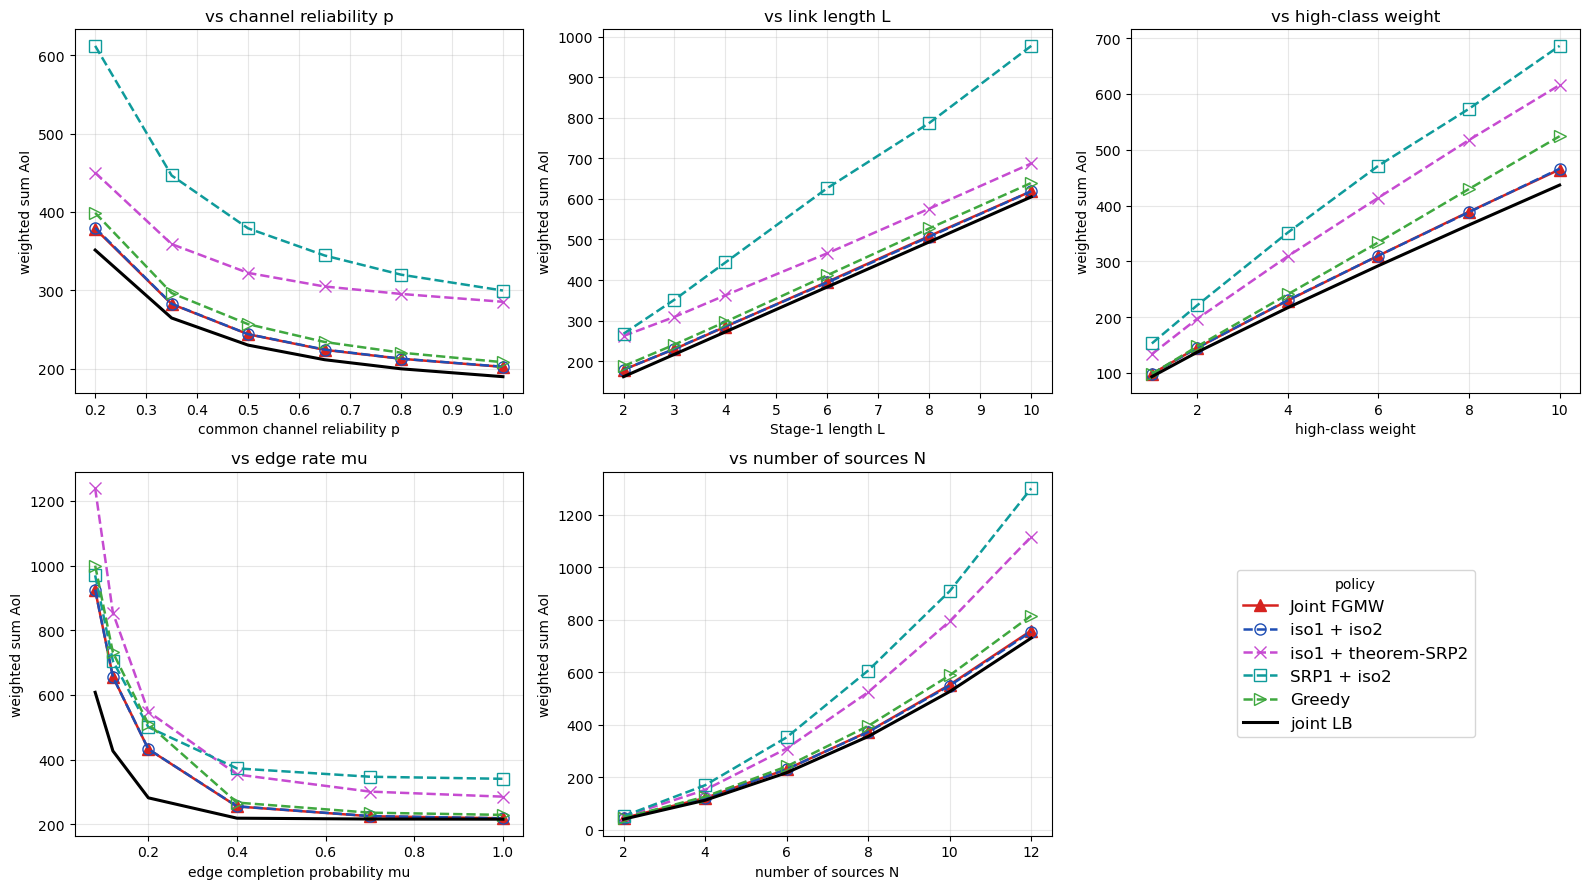

In [30]:
import json
from IPython.display import Markdown

SWEEP_POLICIES = ["Joint FGMW", "iso1 + iso2-lambda", "Greedy", "Uniform"]
RECOMPUTE_SWEEPS = False

if RECOMPUTE_SWEEPS:
    from experiments.quick_heterogeneous_comparison import random_weight_profile, make_channel_configs_from_weights

    BASE_P_LEVELS = np.array([0.95, 0.85, 0.70, 0.55, 0.40, 0.28, 0.18, 0.10], float)
    BASE = dict(N=8, L=3, mu=0.25, weight_ratio=200.0, channel_scale=1.0)
    SWEEP_SPECS = {
        "p":  dict(xlabel="conflict channel scale applied to p_i", values=[0.5,0.65,0.8,0.95,1.1,1.25], key="channel_scale"),
        "L":  dict(xlabel="Stage-1 length L", values=[2,3,4,5,6,8], key="L"),
        "w":  dict(xlabel="log-uniform weight ratio", values=[5,10,25,50,100,200], key="weight_ratio"),
        "mu": dict(xlabel="edge completion probability mu", values=[0.08,0.12,0.18,0.25,0.4,0.7], key="mu"),
        "N":  dict(xlabel="number of heterogeneous sources N", values=[4,6,8,10,12,16], key="N"),
    }

    def _p_levels_for_n(n):
        return BASE_P_LEVELS.copy() if int(n) == 8 else np.geomspace(0.95, 0.10, int(n))

    def _heterogeneous_conflict_network(N, L, mu, weight_ratio, channel_scale):
        w = random_weight_profile(int(N), seed=7, ratio=float(weight_ratio))
        p = make_channel_configs_from_weights(w, _p_levels_for_n(N), seed=11)["conflict"]
        p = np.clip(float(channel_scale) * p, 0.02, 1.0)
        return int(N), int(L), p, float(mu), w

    def run_sweep_v3(name, *, K=6_000, warmup=600, seeds=(0,), K_pilot=8_000, warmup_pilot=800, pilot_seeds=(100,)):
        spec = SWEEP_SPECS[name]
        out = {"x": [], "xlabel": spec["xlabel"], "policies": {k: [] for k in SWEEP_POLICIES}, "lb": []}
        for value in spec["values"]:
            cfg = dict(BASE); cfg[spec["key"]] = value
            n, l, pp, mm, ww = _heterogeneous_conflict_network(**cfg)
            policies, params = build_experiment_v3(n, l, pp, mm, ww)
            lambda_est = estimate_iso1_voq_arrival_rates(n, l, pp, mm, ww, pilot_seeds=pilot_seeds, K_pilot=K_pilot, warmup_pilot=warmup_pilot)
            policies = dict(policies)
            policies["iso1 + iso2-lambda"] = build_iso1_iso2_lambda_policy_v3(n, l, pp, mm, ww, lambda_est["lambda_hat"])
            out["x"].append(value); out["lb"].append(float(n * params["lb_dest_joint"]))
            for pol_name in SWEEP_POLICIES:
                vals = [float(n * TandemAoISimulatorV3(n, l, pp, mm, ww, seed=s).run(policies[pol_name], K=K, warmup=warmup)["weighted_dest_aoi"]) for s in seeds]
                out["policies"][pol_name].append(float(np.mean(vals)))
        return out
    SWEEP_V3 = {nm: run_sweep_v3(nm) for nm in SWEEP_SPECS}
else:
    SWEEP_V3 = json.loads(SWEEP_V3_JSON)

fig, axes = tandem_plotting.plot_sweep_grid(SWEEP_V3)
plt.show()
display(Markdown("The same sweep-grid view now stresses heterogeneous conflict networks. Uniform is intentionally naive, Greedy can over-serve stale but expensive bad-channel sources, and the MW-based policies use constraint-aware tuning that should be more stable across the axes."))


## 9. Heterogeneous channels: paired-seed comparison across binding regimes

Two heterogeneous configurations, each swept in $\mu$ across **edge-bound $\to$ both-multipliers-positive
$\to$ link-bound** (read from the joint KKT duals $\lambda_{\rm link},\nu_{\rm edge}$). For every $\mu$,
Joint FGMW and iso1+iso2 are run under **common random numbers** (the separate-stream design) over 6
paired seeds; we report mean $\pm$ 95% CI and the paired difference. This is the only fair test of
whether joint coordination helps, and where.

- **Config A:** $p=[.9,.7,.4,.2]$, $w=[1,2,4,8]$ ($N=4$)
- **Config B:** $p=[.95,.8,.6,.35,.2,.1]$, $w=[1,1,2,4,6,10]$ ($N=6$, the stress family of Section 7)

Embedded results render immediately; set `RECOMPUTE_HETERO=True` to regenerate with `paired_replications`.

In [31]:
HETERO_V3_JSON = r'''{"A": {"name": "A: p=[.9,.7,.4,.2], w=[1,2,4,8]", "N": 4, "L": 3, "p": [0.9, 0.7, 0.4, 0.2], "w": [1.0, 2.0, 4.0, 8.0], "mu": [0.12, 0.15, 0.18, 0.2, 0.21, 0.25, 0.3], "regime": ["edge", "edge", "edge", "both", "link", "link", "link"], "lam_link": [0.0, 0.0, 0.0, 4.11472390036397, 113.8594285059662, 119.06766986864386, 122.80715911480365], "nu_edge": [1542.389340345282, 992.9717208375223, 693.6328583231661, 544.0352435444947, 0.0, 0.0, 0.0], "joint": {"0.12": [533.2677777777777, 530.5426222222222, 532.4148888888889, 534.2049333333333, 532.9376444444445, 540.4688888888888], "0.15": [443.6978222222222, 443.45511111111114, 441.8820888888889, 436.5335111111111, 444.0749777777778, 447.1372], "0.18": [380.4496888888889, 384.3796888888889, 383.8031555555556, 375.76377777777776, 383.33182222222223, 384.9981333333333], "0.2": [349.62555555555554, 356.57635555555555, 353.19395555555553, 347.95644444444446, 353.92266666666666, 354.2486666666667], "0.21": [331.4467111111111, 341.1520888888889, 338.4954222222222, 333.6296888888889, 341.63306666666665, 338.8547111111111], "0.25": [296.0117333333333, 304.02004444444447, 297.01866666666666, 298.7010222222222, 301.8710222222222, 301.00124444444447], "0.3": [268.33195555555557, 272.5592, 266.28648888888887, 270.55084444444446, 270.74426666666665, 271.4136]}, "iso": {"0.12": [535.9437333333333, 528.2157333333333, 529.3453777777778, 528.5462666666666, 533.3696888888888, 538.9207111111111], "0.15": [445.2960444444444, 441.01315555555556, 441.5316888888889, 434.7458222222222, 445.55724444444445, 447.0570222222222], "0.18": [380.58706666666666, 381.6640888888889, 383.9373777777778, 375.2993333333333, 384.06857777777776, 385.09128888888887], "0.2": [350.6725777777778, 353.5778222222222, 354.11684444444444, 346.2150222222222, 353.80431111111113, 353.59093333333334], "0.21": [336.7050222222222, 339.6891111111111, 340.39875555555557, 335.2927555555556, 341.39324444444446, 340.7727111111111], "0.25": [298.3699111111111, 305.9004888888889, 299.24875555555553, 298.33973333333336, 301.0625333333333, 302.2133777777778], "0.3": [270.15813333333335, 272.86075555555556, 268.80173333333335, 271.07737777777777, 272.13662222222223, 273.32466666666664]}}, "B": {"name": "B: p=[.95,.8,.6,.35,.2,.1], w=[1,1,2,4,6,10]", "N": 6, "L": 3, "p": [0.95, 0.8, 0.6, 0.35, 0.2, 0.1], "w": [1.0, 1.0, 2.0, 4.0, 6.0, 10.0], "mu": [0.1, 0.13, 0.15, 0.17, 0.2, 0.25, 0.3], "regime": ["edge", "edge", "both", "link", "link", "link", "link"], "lam_link": [0.0, 0.0, 83.00851269220584, 373.5071836014977, 379.97000333771575, 385.9083141902229, 389.0458234871039], "nu_edge": [5607.199887709692, 3326.9527297532186, 1969.854141346179, 0.0, 0.0, 0.0, 0.0], "joint": {"0.1": [1306.6707111111573, 1295.715111111094, 1287.1419111110922, 1289.7133333333484, 1292.5579555555744, 1312.2590222222561], "0.13": [1060.0520000000042, 1040.9027111111068, 1062.6846666666506, 1059.3900444444444, 1060.9332444444317, 1072.8692444444687], "0.15": [945.682622222221, 929.5808000000056, 934.4759111111109, 930.2873777777565, 944.8308888889028, 951.2692888888922], "0.17": [845.9832888888827, 833.5605777777791, 835.0383555555572, 833.4747111111201, 853.6568444444397, 842.3005777777853], "0.2": [762.4331999999956, 748.0637777777581, 753.694577777777, 750.2075555555597, 771.440755555552, 751.5067999999907], "0.25": [675.0597777777738, 670.7798222222173, 676.5586222222155, 677.6762666666775, 692.7191111110975, 682.8728888888666], "0.3": [646.3914222222244, 629.2837333333155, 633.3884444444438, 629.1382666666836, 637.7376888888863, 635.6423111111023]}, "iso": {"0.1": [1298.8642666666094, 1278.0698666666667, 1269.7649777777847, 1272.6463111110868, 1270.8692000000374, 1296.4826222222107], "0.13": [1053.0187999999923, 1018.860622222219, 1035.80377777779, 1032.4394666666701, 1042.6083999999923, 1053.2706666666463], "0.15": [941.0322222222014, 920.2757777777599, 920.1076888888997, 915.4819999999945, 932.1192444444541, 934.1295111111144], "0.17": [854.8195111111306, 839.1824444444264, 839.599066666668, 837.1294222222135, 851.7916888888859, 848.189600000004], "0.2": [770.0971555555574, 748.0906666666532, 761.2412444444496, 756.2247111111012, 768.0159999999776, 760.075155555557], "0.25": [687.7878222222271, 671.5972888888836, 675.3417777777798, 682.7514222222139, 684.7311111110812, 679.747599999996], "0.3": [646.898711111114, 626.6713777777878, 633.1068000000031, 644.1451111111138, 640.6037777777626, 635.9252444444551]}}}'''

Config A: A: p=[.9,.7,.4,.2], w=[1,2,4,8]  (6 paired seeds, common random numbers)
     mu regime  lam_lnk   nu_edg         joint     iso1+iso2       diff(J-I)
   0.12   edge     0.00   1542.4    534.0+-2.7    532.4+-3.5      1.58+-2.31
   0.15   edge     0.00    993.0    442.8+-2.8    442.5+-3.6      0.26+-1.32
   0.18   edge     0.00    693.6    382.1+-2.8    381.8+-2.9      0.35+-0.98
    0.2   both     4.11    544.0    352.6+-2.6    352.0+-2.5      0.59+-1.26
   0.21   link   113.86      0.0    337.5+-3.3    339.0+-2.0     -1.51+-1.83
   0.25   link   119.07      0.0    299.8+-2.4    300.9+-2.3     -1.09+-1.09
    0.3   link   122.81      0.0    270.0+-1.8    271.4+-1.4     -1.41+-0.68  significant

Config B: B: p=[.95,.8,.6,.35,.2,.1], w=[1,1,2,4,6,10]  (6 paired seeds, common random numbers)
     mu regime  lam_lnk   nu_edg         joint     iso1+iso2       diff(J-I)
    0.1   edge     0.00   5607.2   1297.3+-8.0   1281.1+-10.5     16.23+-3.67  significant
   0.13   edge     0.00

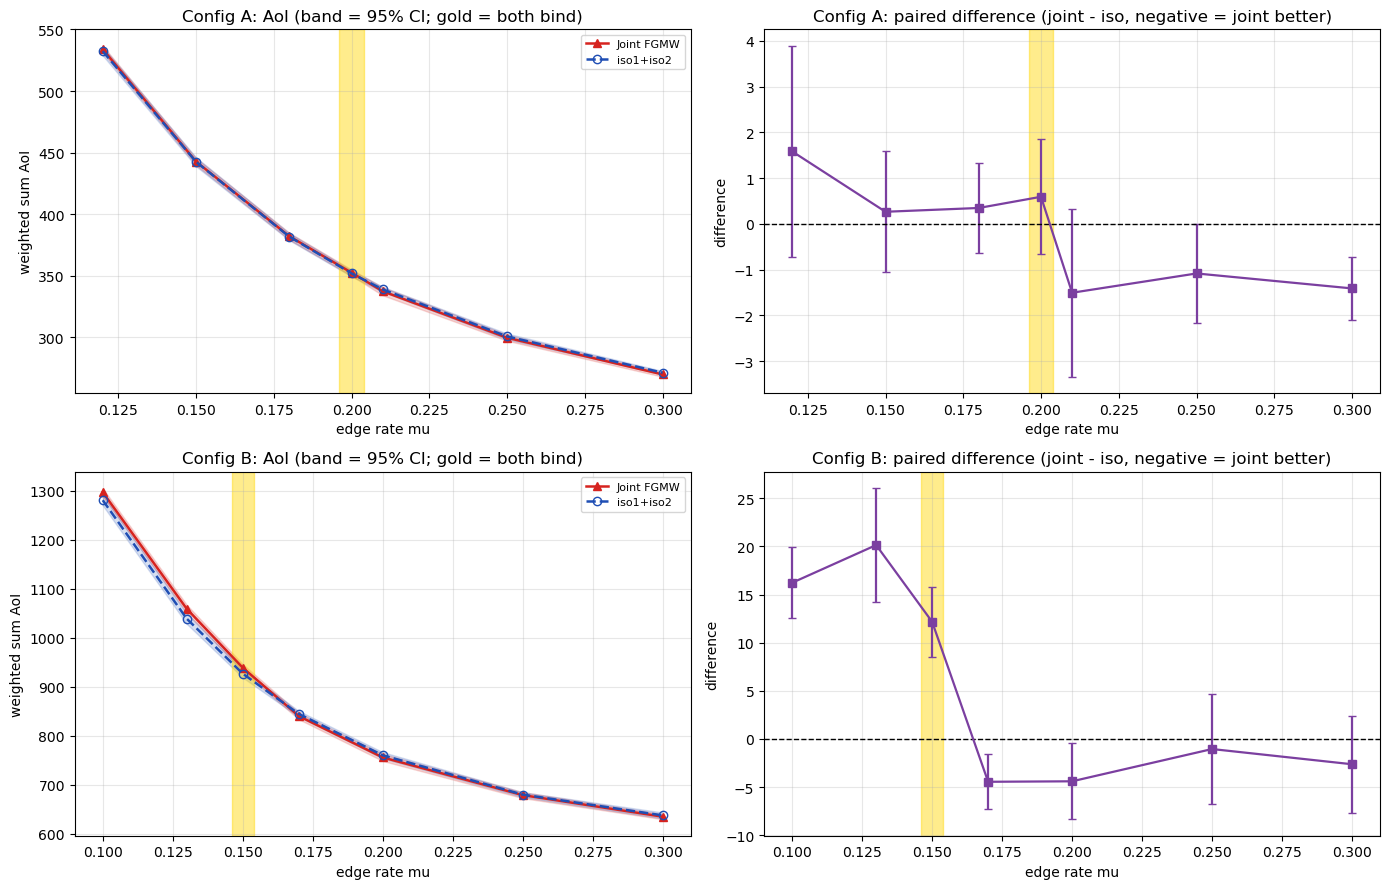

In [32]:
HV = json.loads(HETERO_V3_JSON)

RECOMPUTE_HETERO = False
if RECOMPUTE_HETERO:
    def _regime(J):
        d = J["dual"]
        return "both" if (d["lambda_link"] > 1e-6 and d["nu_edge"] > 1e-6) else ("edge" if d["nu_edge"] > 1e-6 else "link")
    def _sweep_cfg(name, N, L, p, w, mus, seeds=range(6), K=25_000, warm=2_500):
        out = dict(name=name, N=N, L=L, p=list(p), w=list(w), mu=list(mus),
                   regime=[], lam_link=[], nu_edge=[], joint={}, iso={})
        for mu in mus:
            J = joint_params_v3(N, L, p, mu, w); out["regime"].append(_regime(J))
            out["lam_link"].append(float(J["dual"]["lambda_link"])); out["nu_edge"].append(float(J["dual"]["nu_edge"]))
            pols, _ = build_experiment_v3(N, L, p, mu, w)
            out["joint"][f"{mu}"] = [float(N * TandemAoISimulatorV3(N, L, p, mu, w, seed=s).run(pols["Joint FGMW"], K, warm)["weighted_dest_aoi"]) for s in seeds]
            out["iso"][f"{mu}"]  = [float(N * TandemAoISimulatorV3(N, L, p, mu, w, seed=s).run(pols["iso1 + iso2"], K, warm)["weighted_dest_aoi"]) for s in seeds]
        return out
    HV = {"A": _sweep_cfg("A: p=[.9,.7,.4,.2], w=[1,2,4,8]", 4, 3, [0.9,0.7,0.4,0.2], [1.,2.,4.,8.], [0.12,0.15,0.18,0.20,0.21,0.25,0.30]),
          "B": _sweep_cfg("B: p=[.95,.8,.6,.35,.2,.1], w=[1,1,2,4,6,10]", 6, 3, [0.95,0.80,0.60,0.35,0.20,0.10], [1.,1.,2.,4.,6.,10.], [0.10,0.13,0.15,0.17,0.20,0.25,0.30])}

def _ci(a):
    a = np.asarray(a, float); return a.mean(), 1.96 * a.std(ddof=1) / np.sqrt(len(a))

for key in ["A", "B"]:
    d = HV[key]; nseed = len(d["joint"][f"{d['mu'][0]}"])
    print(f"Config {key}: {d['name']}  ({nseed} paired seeds, common random numbers)")
    print(f"  {'mu':>5}{'regime':>7}{'lam_lnk':>9}{'nu_edg':>9}{'joint':>14}{'iso1+iso2':>14}{'diff(J-I)':>16}")
    for k, mu in enumerate(d["mu"]):
        jm, je = _ci(d["joint"][f"{mu}"]); im, ie = _ci(d["iso"][f"{mu}"])
        dd = np.array(d["joint"][f"{mu}"]) - np.array(d["iso"][f"{mu}"]); dm, de = _ci(dd)
        sig = "  significant" if abs(dm) > de else ""
        print(f"  {mu:>5}{d['regime'][k]:>7}{d['lam_link'][k]:>9.2f}{d['nu_edge'][k]:>9.1f}"
              f"{jm:>9.1f}+-{je:<3.1f}{im:>9.1f}+-{ie:<3.1f}{dm:>10.2f}+-{de:<4.2f}{sig}")
    print()

fig, axes = tandem_plotting.plot_heterogeneous_binding_regimes(HV, _ci)
plt.show()


## 9a. Quick random heterogeneous comparison

Supplemental short-run comparison for the Igor meeting: random log-uniform weights and three heterogeneous channel pairings. The policies are Joint FGMW, isolated MW, Downstream-Aware MW, Greedy, and Uniform; SRP baselines are intentionally not included in this quick diagnostic.


In [ ]:
from experiments.quick_heterogeneous_comparison import quick_random_heterogeneous_comparison

quick_het = quick_random_heterogeneous_comparison()
quick_profiles = quick_het["profiles"]
quick_results = quick_het["results"]

quick_profile_view = quick_profiles[[
    "source", "w",
    "p_aligned", "p_neutral", "p_conflict",
    "c_aligned", "c_neutral", "c_conflict",
]]
display(quick_profile_view.round(4))

quick_result_view = quick_results[[
    "config", "policy", "weighted_dest_aoi", "weighted_dest_aoi_se",
    "gap_vs_iso_pct", "corr_w_c", "stage1_used_frac", "stage2_used_frac",
    "gap_vs_iso_lambda_pct", "corr_w_c", "stage1_used_frac", "stage2_used_frac",
    "stage2_idle_empty_frac", "total_VOQ_arrival_rate", "total_delivery_rate",
    "total_overwrite_rate", "lambda_link", "nu_edge", "lambda_hat_min",
    "lambda_hat_max", "lambda_hat_sum", "qd_iso2_relaxed_sum", "qd_iso2_lambda_sum",
]]
display(quick_result_view.round(4))

fig, ax = tandem_plotting.plot_quick_heterogeneous_aoi(quick_results)
plt.show()

fig, ax = tandem_plotting.plot_quick_heterogeneous_gap_vs_iso(quick_results)
plt.show()

fig, ax = tandem_plotting.plot_quick_heterogeneous_gap_vs_iso_lambda(quick_results)
plt.show()

fig, axes = tandem_plotting.plot_quick_heterogeneous_pipeline(quick_results)
plt.show()


## 9b. Systematic heterogeneous screening

This section loads the screening CSV when available. It intentionally does not recompute the full grid during notebook execution; run `python experiments/heterogeneous_screening.py --full` from the repository root to regenerate the full screen.

In [ ]:
from pathlib import Path

screening_path = Path("results/heterogeneous_screening.csv")
if screening_path.exists():
    screening_df = pd.read_csv(screening_path)
    print(f"Loaded {screening_path} with {len(screening_df)} rows; mode(s): {sorted(screening_df['screening_mode'].unique())}")
    display(screening_df.head(15).round(4))
    screening_summary = (
        screening_df[screening_df["policy"].isin(["Joint FGMW", "Greedy"])]
        .groupby(["policy", "alignment"])["gap_vs_iso_lambda_pct"]
        .agg(["mean", "min", "max", "count"])
        .reset_index()
    )
    display(screening_summary.round(4))

    fig, ax = tandem_plotting.plot_screening_joint_gap_by_regime(screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_screening_greedy_gap_by_alignment(screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_screening_joint_heatmap(screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_screening_greedy_heatmap(screening_df)
    plt.show()
else:
    print("Screening CSV not found. Run: python experiments/heterogeneous_screening.py --full")


## 9c. SRP-inclusive heterogeneous screening

This supplemental diagnostic compares stationary randomized policy baselines against the MW policies. `SRP-iso` combines the exact isolated Stage-1 SRP optimizer with the lambda-aware isolated Stage-2 SRP target. `SRP-tandem-LB` uses a single lower-bound-induced target rate vector for both Stage-1 refreshes and Stage-2 deliveries. The comparison tests whether that one-rate tandem SRP design is too restrictive in heterogeneous networks.

The notebook only loads `results/heterogeneous_screening_with_srp.csv` when it exists; it does not rerun the full SRP-inclusive screening grid.


In [ ]:
from pathlib import Path

srp_screening_path = Path("results/heterogeneous_screening_with_srp.csv")
srp_policy_order = [
    "iso1 + iso2-lambda",
    "Joint FGMW",
    "Downstream-Aware MW",
    "Greedy",
    "Uniform",
    "SRP-iso",
    "SRP-tandem-LB",
]
srp_summary_metrics = [
    "weighted_dest_aoi",
    "gap_vs_iso_lambda_pct",
    "stage2_idle_empty_frac",
    "total_VOQ_arrival_rate",
    "total_delivery_rate",
    "total_overwrite_rate",
]
srp_only_metrics = [
    "gap_vs_iso_lambda_pct",
    "srp_alpha_sum",
    "srp_beta_sum",
    "srp_stage1_target_sum",
    "srp_stage2_target_sum",
    "total_VOQ_arrival_rate",
    "total_delivery_rate",
    "total_overwrite_rate",
    "stage2_idle_empty_frac",
]

if srp_screening_path.exists():
    srp_screening_df = pd.read_csv(srp_screening_path)
    print(f"Loaded {srp_screening_path} with {len(srp_screening_df)} rows; mode(s): {sorted(srp_screening_df['screening_mode'].unique())}")

    present_policies = [p for p in srp_policy_order if p in set(srp_screening_df["policy"])]
    srp_high_level = (
        srp_screening_df[srp_screening_df["policy"].isin(present_policies)]
        .groupby(["policy", "alignment"])[srp_summary_metrics]
        .mean()
        .reset_index()
    )
    srp_high_level["policy"] = pd.Categorical(srp_high_level["policy"], present_policies, ordered=True)
    srp_high_level = srp_high_level.sort_values(["policy", "alignment"])
    display(srp_high_level.round(4))

    srp_only = (
        srp_screening_df[srp_screening_df["policy"].isin(["SRP-iso", "SRP-tandem-LB"])]
        .groupby(["alignment", "policy"])[srp_only_metrics]
        .mean()
        .reset_index()
        .sort_values(["alignment", "policy"])
    )
    display(srp_only.round(4))

    fig, ax = tandem_plotting.plot_srp_iso_vs_tandem_gap_by_alignment(srp_screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_srp_iso_vs_tandem_gap_by_regime(srp_screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_srp_tandem_minus_iso_gap(srp_screening_df)
    plt.show()

    fig, axes = tandem_plotting.plot_srp_pipeline_diagnostics(srp_screening_df)
    plt.show()
else:
    print("Run python experiments/heterogeneous_screening_with_srp.py --quick or --full first.")


If `SRP-tandem-LB` is worse than `SRP-iso`, this does not mean joint optimization is useless. The current tandem SRP is a one-rate lower-bound-induced design: it uses the same target rate vector for Stage-1 refreshes and Stage-2 deliveries. In AoI systems, upstream refresh rate and downstream delivery rate may need to differ because VOQ overwriting can keep packets fresh. This motivates a future two-rate tandem SRP design, but that design is not implemented here.


### What the two configurations show

- **Link-bound regimes (both configs agree):** Joint FGMW is slightly **better** — about $0.5\%$,
  statistically significant — because with heterogeneous $c_i$ the joint ES tunes to $\sqrt{w_ic_i}$
  while iso2 tunes to $\sqrt{w_i}$, so the link-supply-aware ordering helps.
- **Edge / both-bound regimes (sign is config-dependent):** Config A is within noise, but Config B
  shows Joint FGMW **significantly *worse* by $1$–$2\%$** — the joint $q^\dagger$ folds the link
  constraint into the edge allocation even when the edge is the true bottleneck, mis-allocating relative
  to iso2's edge-only tuning.
- **Net:** the gap is small ($<2\%$) everywhere and its **sign tracks the binding constraint**, so
  Joint FGMW is **not uniformly better than isolated MW**. This is consistent with the one-slot FGMW
  coupling the stages only through *offline* $q^\dagger$ tuning (the BS index is $A^Q$-only); a robust,
  larger gain would require a cross-stage Lyapunov term, per the checklist.

## 10. Interpretation checklist

1. Compare achieved VOQ-arrival and delivery rates with $q^\dagger$, but do not call $q^\dagger$ an
   enforced rate under max-weight.
2. Separate a poor randomized priority rule from avoidable non-work-conserving idling by reporting both
   SRP2 variants.
3. Use heterogeneous $p_i$ and configurations with positive link **and** edge KKT multipliers when
   looking for structural joint-allocation effects.
4. Report **paired multi-seed** differences with confidence intervals whenever Joint FGMW and isolated
   MW are close — single-seed gaps (e.g. the Section 7 stress case) are not conclusive on their own.
5. **The joint advantage is not uniform.** Across binding regimes (Section 9) the gap is $<2\%$ and its
   sign flips: Joint FGMW is mildly better when the link binds and can be significantly worse when the
   edge binds. Near-equivalence — or a small regime-dependent loss — should motivate a new cross-stage
   Lyapunov term (the $L>1$ joint BS index depends on $A_i^Q$ and offline coefficients, not on the
   instantaneous downstream gap $Q_i$), rather than being read as proof that coupling is unnecessary.